# Detection number vs. $T_{\rm delay}$

Read LISA/Taiji/TianQin space-network + LGWA event-count summaries from `code/space_event_count_lgwa/` and plot detection number against delay time.

The notebook parses both single-delay summary files and multi-delay aggregate files. It ignores `*_samples.txt` files and uses the per-delay summary dictionaries in each `.txt` file.


In [1]:
from pathlib import Path
import ast
import re

import matplotlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
matplotlib.rcParams['text.usetex'] = True

%config InlineBackend.figure_format = 'retina'
plt.rc('text', usetex=True)
plt.rc('font', family='serif')

plt.rcParams.update({
    'figure.figsize': (8.0, 5.2),
    'font.size': 18,
    'axes.grid': True,
    'grid.linestyle': ':',
})

RESULT_DIR = Path('space_event_count_lgwa')
if not RESULT_DIR.exists():
    RESULT_DIR = Path('code/space_event_count_lgwa')

RESULT_DIR


PosixPath('space_event_count_lgwa')

In [2]:
def parse_summary_line(line):
    line = line.strip()
    if not line or not line.startswith('{'):
        return None
    try:
        return ast.literal_eval(line)
    except (SyntaxError, ValueError):
        return None


def detector_from_filename(path):
    name = path.name
    match = re.search(r'fullband_detected_(.*?)_fullpop_madau', name)
    if not match:
        return None
    return match.group(1).replace('_', '-').replace('tianqin', 'TianQin').replace('lisa', 'LISA').replace('taiji', 'Taiji')


def rows_from_summary_file(path):
    rows = []
    text = path.read_text().splitlines()
    parsed = [item for item in (parse_summary_line(line) for line in text) if item is not None]
    if not parsed:
        return rows

    fallback_network = detector_from_filename(path)
    for item in parsed:
        if 'Tdelay_yr' not in item:
            continue
        row = dict(item)
        row['source_file'] = path.name
        row['network'] = row.get('space_detector_network') or fallback_network
        row['Tdelay_yr'] = float(row['Tdelay_yr'])
        row['Nspace'] = float(row.get('Nspace', np.nan))
        row['Nspace_lgwa'] = float(row.get('Nspace_lgwa', np.nan))
        row['rspace'] = float(row.get('rspace', np.nan))
        row['rspace_lgwa'] = float(row.get('rspace_lgwa', np.nan))
        row['z_max'] = float(row.get('z_max', np.nan))
        row['rho_thr'] = float(row.get('rho_thr', np.nan))
        row['n_samples'] = int(row.get('n_samples', 0))
        rows.append(row)
    return rows


summary_files = sorted(path for path in RESULT_DIR.glob('*.txt') if not path.name.endswith('_samples.txt'))
rows = []
for path in summary_files:
    rows.extend(rows_from_summary_file(path))

df = pd.DataFrame(rows)
print(f'Read {len(summary_files)} summary files and {len(df)} per-delay rows from {RESULT_DIR}')
df.head()


Read 15 summary files and 144 per-delay rows from space_event_count_lgwa


,model,detection_mode,space_detector_network,space_detectors,followup_detector,R0,Tobs_space_yr,Tobs_lgwa_yr,Tdelay_yr,T_window_yr,...,redshift_weight_integral_Gpc3,mean_space_window_yr,mean_space_lgwa_filtered_window_yr,Nspace,rspace,Nspace_lgwa,rspace_lgwa,n_saved_space_lgwa_detected,source_file,network
0,fullpop_madau,space_network_detected_then_lgwa_threshold_fil...,LISA,"(LISA,)",LGWA,19.0,4.0,10.0,0.0,"(0.0, 14.0)",...,12.470113,0.004834,0.004834,1.145339,0.286335,1.145339,0.286335,1334,space_event_count_lgwa_fullband_detected_lisa_...,LISA
1,fullpop_madau,space_network_detected_then_lgwa_threshold_fil...,LISA,"(LISA,)",LGWA,19.0,4.0,10.0,-9.0,"(0.0, 5.0)",...,12.470113,0.001697,0.001697,0.402190,0.100547,0.402190,0.100547,1333,space_event_count_lgwa_fullband_detected_lisa_...,LISA
2,fullpop_madau,space_network_detected_then_lgwa_threshold_fil...,LISA,"(LISA,)",LGWA,19.0,4.0,10.0,-8.0,"(0.0, 6.0)",...,12.470113,0.002193,0.002193,0.519511,0.129878,0.519511,0.129878,1317,space_event_count_lgwa_fullband_detected_lisa_...,LISA
3,fullpop_madau,space_network_detected_then_lgwa_threshold_fil...,LISA,"(LISA,)",LGWA,19.0,4.0,10.0,-7.0,"(0.0, 7.0)",...,12.470113,0.002686,0.002686,0.636417,0.159104,0.636417,0.159104,1340,space_event_count_lgwa_fullband_detected_lisa_...,LISA
4,fullpop_madau,space_network_detected_then_lgwa_threshold_fil...,LISA,"(LISA,)",LGWA,19.0,4.0,10.0,-6.0,"(0.0, 8.0)",...,12.470113,0.003072,0.003072,0.727880,0.181970,0.727880,0.181970,1354,space_event_count_lgwa_fullband_detected_lisa_...,LISA


In [3]:
if df.empty:
    raise RuntimeError(f'No summary rows found in {RESULT_DIR}')

# If the same network/Tdelay appears in multiple runs, keep the row with the largest z_max, then largest n_samples.
# Change this filtering if you want to compare all files separately.
plot_df = (
    df.sort_values(['network', 'Tdelay_yr', 'z_max', 'n_samples'])
      .groupby(['network', 'Tdelay_yr'], as_index=False)
      .tail(1)
      .sort_values(['network', 'Tdelay_yr'])
      .reset_index(drop=True)
)

plot_df[['network', 'Tdelay_yr', 'Nspace', 'Nspace_lgwa', 'z_max', 'n_samples', 'source_file']].head(20)


,network,Tdelay_yr,Nspace,Nspace_lgwa,z_max,n_samples,source_file
0,LISA,-10.0,0.254303,0.254303,0.3,2000000,space_event_count_lgwa_fullband_detected_lisa_...
1,LISA,-9.0,0.402190,0.402190,0.3,2000000,space_event_count_lgwa_fullband_detected_lisa_...
2,LISA,-8.0,0.519511,0.519511,0.3,2000000,space_event_count_lgwa_fullband_detected_lisa_...
3,LISA,-7.0,0.636417,0.636417,0.3,2000000,space_event_count_lgwa_fullband_detected_lisa_...
4,LISA,-6.0,0.727880,0.727880,0.3,2000000,space_event_count_lgwa_fullband_detected_lisa_...
5,LISA,-5.0,0.805219,0.805219,0.3,2000000,space_event_count_lgwa_fullband_detected_lisa_...
6,LISA,-4.0,0.857496,0.857496,0.3,2000000,space_event_count_lgwa_fullband_detected_lisa_...
7,LISA,-3.0,0.997481,0.997481,0.3,2000000,space_event_count_lgwa_fullband_detected_lisa_...
8,LISA,-2.0,1.003262,1.003262,0.3,2000000,space_event_count_lgwa_fullband_detected_lisa_...
9,LISA,-1.0,1.086794,1.086794,0.3,2000000,space_event_count_lgwa_fullband_detected_lisa_...


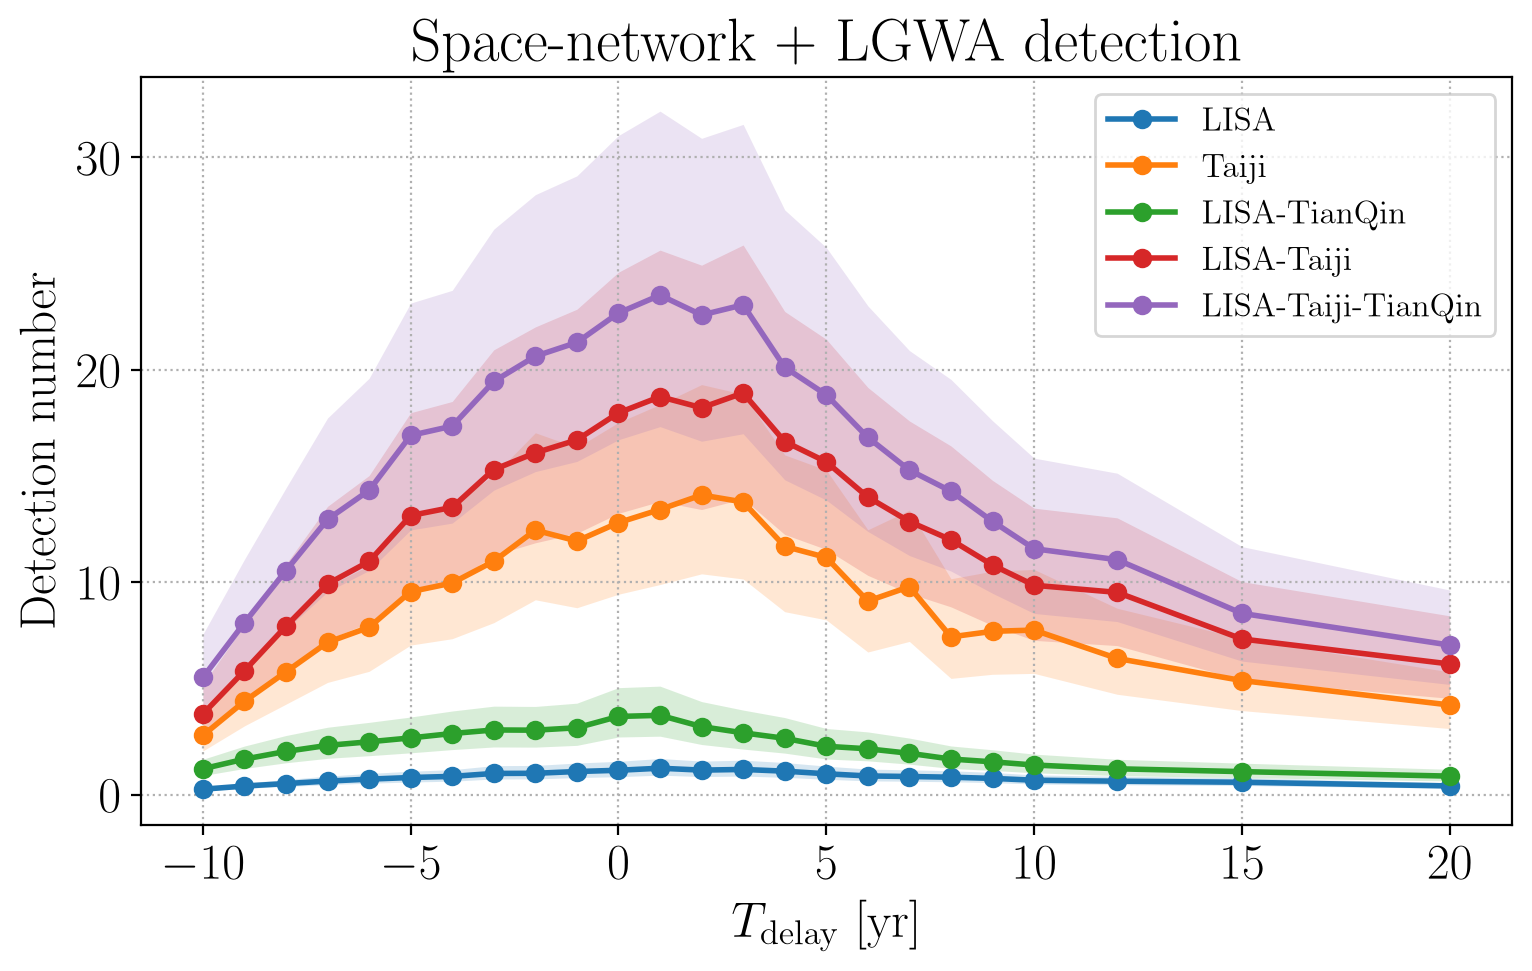

In [7]:
network_order = ['LISA', 'Taiji', 'LISA-TianQin', 'LISA-Taiji', 'LISA-Taiji-TianQin']
ordered_networks = [name for name in network_order if name in set(plot_df['network'])]
# ordered_networks += [name for name in sorted(set(plot_df['network'])) if name not in ordered_networks]

lower_scale = 14.0 / 19.0
upper_scale = 26.0 / 19.0

fig, ax = plt.subplots()
for network in ordered_networks:
    group = plot_df[plot_df['network'] == network].sort_values('Tdelay_yr')
    x = group['Tdelay_yr'].to_numpy()
    y = group['Nspace_lgwa'].to_numpy()
    line, = ax.plot(x, y, marker='o', lw=2, label=network)
    ax.fill_between(x, y * lower_scale, y * upper_scale, color=line.get_color(), alpha=0.18, linewidth=0)

ax.set_xlabel(r'$T_{\rm delay}$ [yr]')
ax.set_ylabel(r'Detection number')
ax.set_title('Space-network + LGWA detection')
ax.legend(fontsize=12)
plt.tight_layout()
plt.savefig('../plots/space_event_count_lgwa.png', dpi=300, bbox_inches='tight')
plt.show()


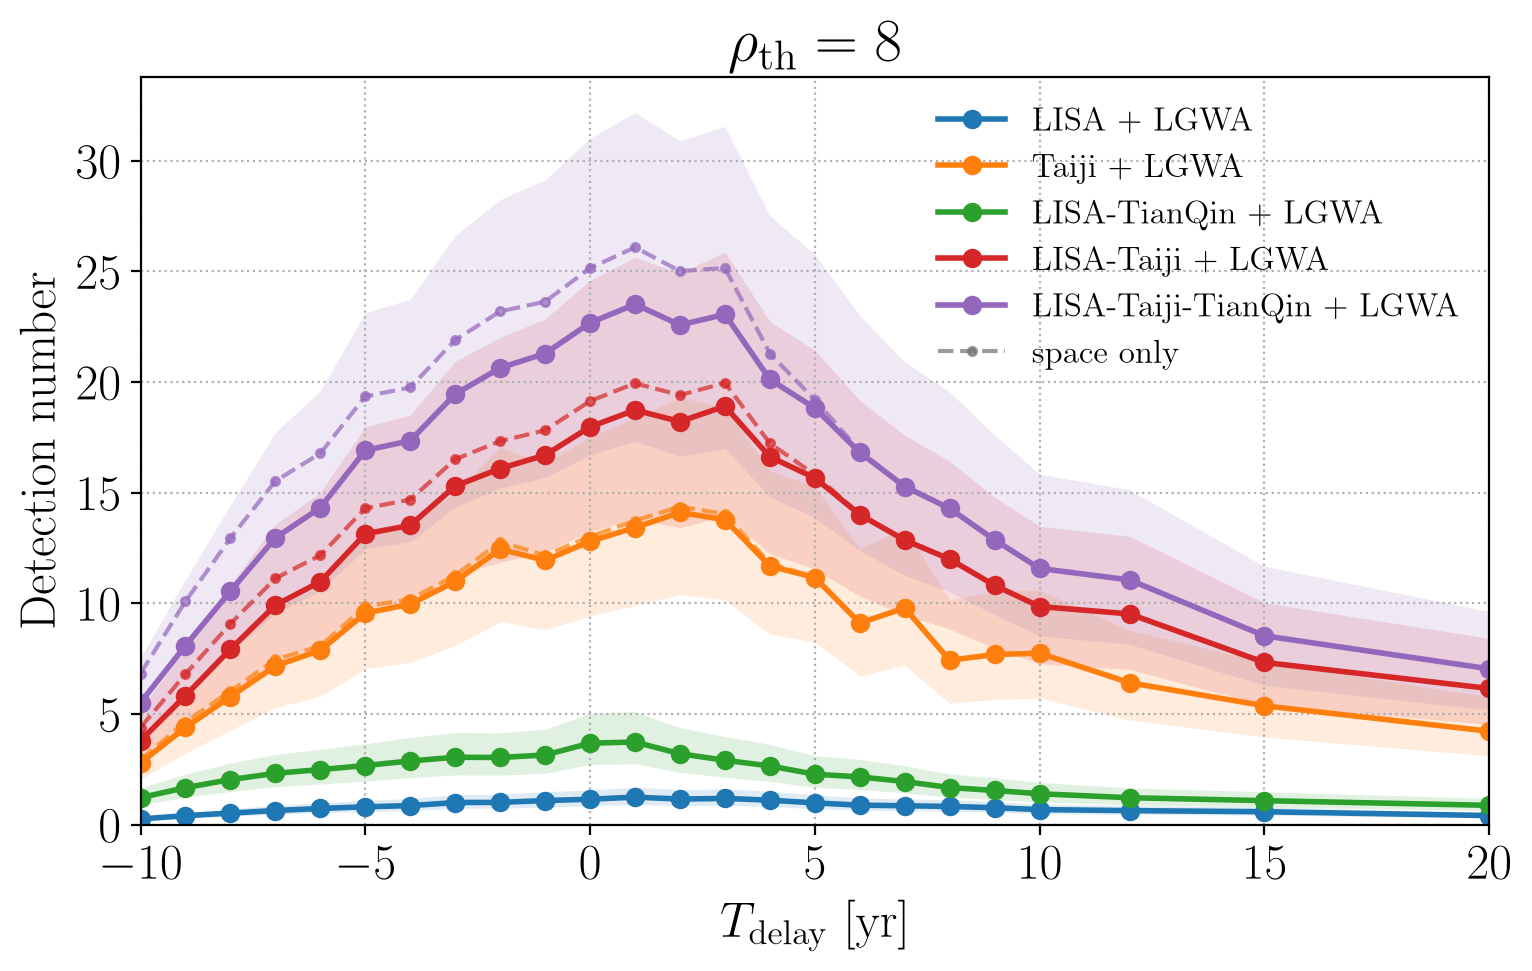

In [9]:
# Optional: compare the space-network-only count to the LGWA-filtered count.
fig, ax = plt.subplots()
legend_handles = []
for network in ordered_networks:
    group = plot_df[plot_df['network'] == network].sort_values('Tdelay_yr')
    x = group['Tdelay_yr'].to_numpy()
    y_space = group['Nspace'].to_numpy()
    y_lgwa = group['Nspace_lgwa'].to_numpy()
    line, = ax.plot(x, y_lgwa, ls='-', marker='o', lw=2, label=f'{network} + LGWA')
    color = line.get_color()
    legend_handles.append(line)
    if not np.allclose(y_space, y_lgwa, rtol=1.0e-10, atol=1.0e-12, equal_nan=True):
        ax.plot(x, y_space, color=color, ls='--', marker='.', alpha=0.7, label='_nolegend_')
    ax.fill_between(x, y_lgwa * lower_scale, y_lgwa * upper_scale, color=color, alpha=0.14, linewidth=0)

legend_handles.append(plt.Line2D([0], [0], color='0.45', ls='--', marker='.', alpha=0.7, label='space only'))
ax.set_xlim(-10,20)
ax.set_ylim(0)
ax.set_xlabel(r'$T_{\rm delay}$ [yr]')
ax.set_ylabel('Detection number')
ax.set_title(r'$\rho_{\rm th}=8$')
ax.legend(handles=legend_handles, frameon=False, fontsize=12)
plt.tight_layout()
plt.savefig('../plots/space_event_count_lgwa_1.png', dpi=600, bbox_inches='tight')
plt.show()


In [49]:
# Save a CSV table for reuse.
out_csv = RESULT_DIR / 'detection_number_vs_Tdelay_table.csv'
plot_df.to_csv(out_csv, index=False)
out_csv


PosixPath('space_event_count_lgwa/detection_number_vs_Tdelay_table.csv')

In [10]:
RESULT_DIR = Path('space_event_count_lgwa/rho_5')

summary_files = sorted(path for path in RESULT_DIR.glob('*.txt') if not path.name.endswith('_samples.txt'))
rows = []
for path in summary_files:
    rows.extend(rows_from_summary_file(path))

df_rho5 = pd.DataFrame(rows)
if df_rho5.empty:
    raise RuntimeError(f'No summary rows found in {RESULT_DIR}')

# If the same network/Tdelay appears in multiple runs, keep the row with the largest z_max, then largest n_samples.
# Change this filtering if you want to compare all files separately.
plot_df_rho5 = (
    df_rho5.sort_values(['network', 'Tdelay_yr', 'z_max', 'n_samples'])
      .groupby(['network', 'Tdelay_yr'], as_index=False)
      .tail(1)
      .sort_values(['network', 'Tdelay_yr'])
      .reset_index(drop=True)
)


In [13]:
network_order = ['LISA', 'Taiji', 'LISA-TianQin', 'LISA-Taiji', 'LISA-Taiji-TianQin']
ordered_networks = [name for name in network_order if name in set(plot_df_rho5['network'])]
# ordered_networks += [name for name in sorted(set(plot_df_rho5['network'])) if name not in ordered_networks]

lower_scale = 14.0 / 19.0
upper_scale = 26.0 / 19.0


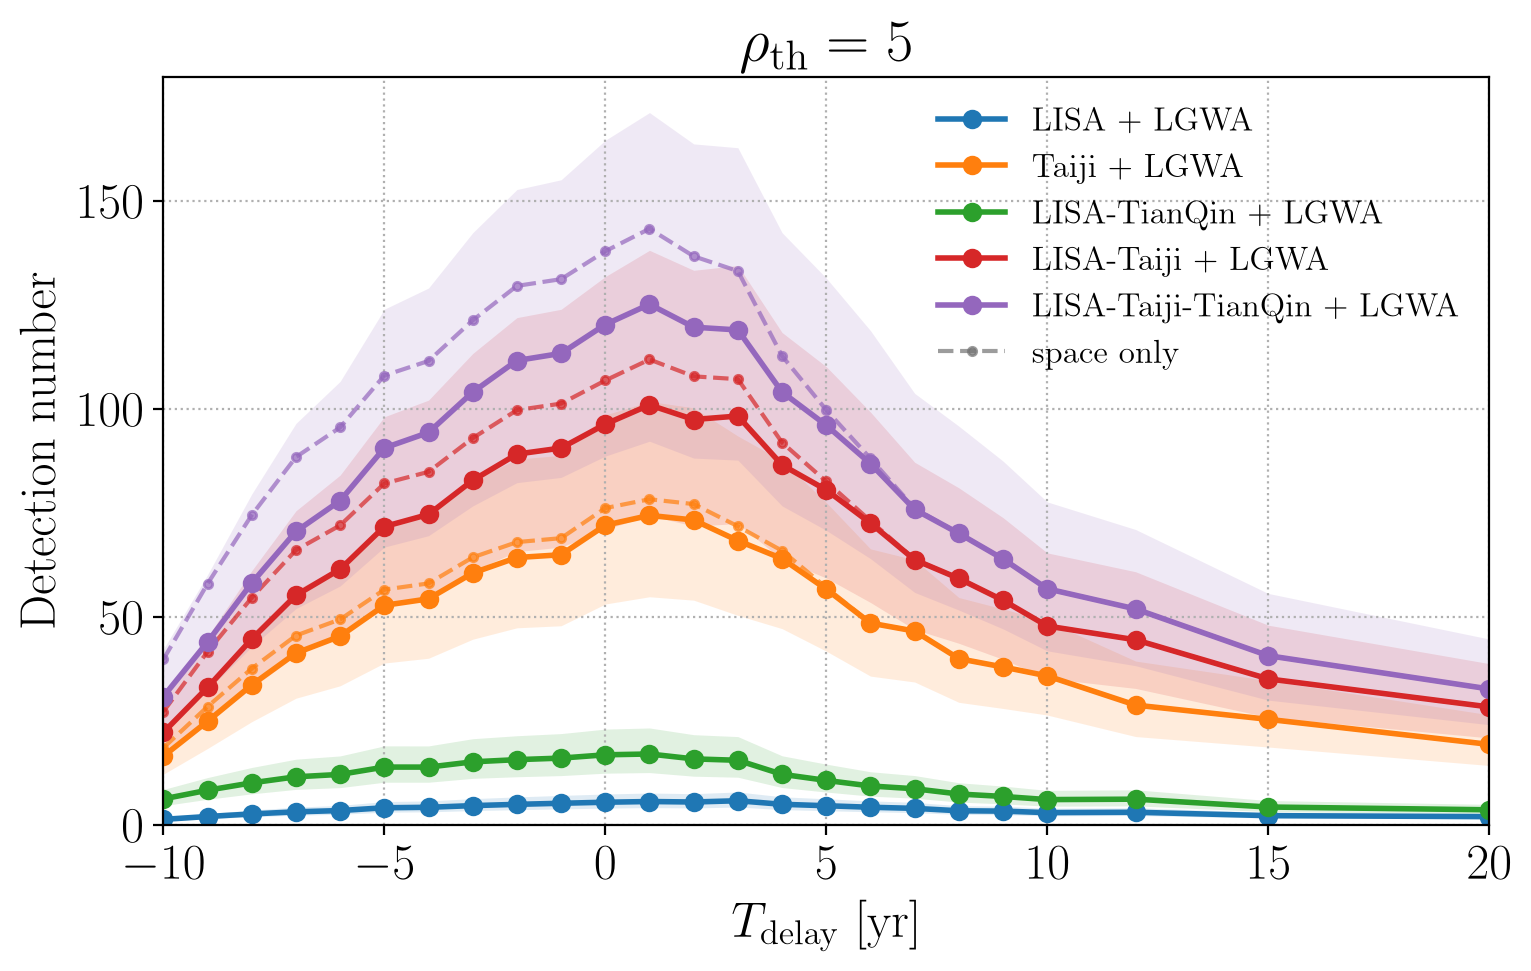

In [14]:
# Optional: compare the space-network-only count to the LGWA-filtered count.
fig, ax = plt.subplots()
legend_handles = []
for network in ordered_networks:
    group = plot_df_rho5[plot_df_rho5['network'] == network].sort_values('Tdelay_yr')
    x = group['Tdelay_yr'].to_numpy()
    y_space = group['Nspace'].to_numpy()
    y_lgwa = group['Nspace_lgwa'].to_numpy()
    line, = ax.plot(x, y_lgwa, ls='-', marker='o', lw=2, label=f'{network} + LGWA')
    color = line.get_color()
    legend_handles.append(line)
    if not np.allclose(y_space, y_lgwa, rtol=1.0e-10, atol=1.0e-12, equal_nan=True):
        ax.plot(x, y_space, color=color, ls='--', marker='.', alpha=0.7, label='_nolegend_')
    ax.fill_between(x, y_lgwa * lower_scale, y_lgwa * upper_scale, color=color, alpha=0.14, linewidth=0)

legend_handles.append(plt.Line2D([0], [0], color='0.45', ls='--', marker='.', alpha=0.7, label='space only'))
ax.set_xlim(-10,20)
ax.set_ylim(0)
ax.set_xlabel(r'$T_{\rm delay}$ [yr]')
ax.set_ylabel('Detection number')
ax.set_title(r'$\rho_{\rm th}=5$')
ax.legend(handles=legend_handles, frameon=False, fontsize=12)
plt.tight_layout()
plt.savefig('../plots/space_event_count_lgwa_rho5_1.png', dpi=300, bbox_inches='tight')
plt.show()


Read 11 AMIGO summary files at rho=8 from space_event_count_amigo
  LISA: Tdelay = [np.float64(-7.0), np.float64(-6.0), np.float64(-5.0), np.float64(-4.0), np.float64(-3.0), np.float64(-2.0), np.float64(-1.0), np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0), np.float64(9.0), np.float64(10.0), np.float64(15.0), np.float64(20.0)]
  LISA-Taiji-TianQin: Tdelay = [np.float64(-7.0), np.float64(-6.0), np.float64(-5.0), np.float64(-4.0), np.float64(-3.0), np.float64(-2.0), np.float64(-1.0), np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0), np.float64(9.0), np.float64(10.0), np.float64(12.0), np.float64(15.0), np.float64(20.0)]


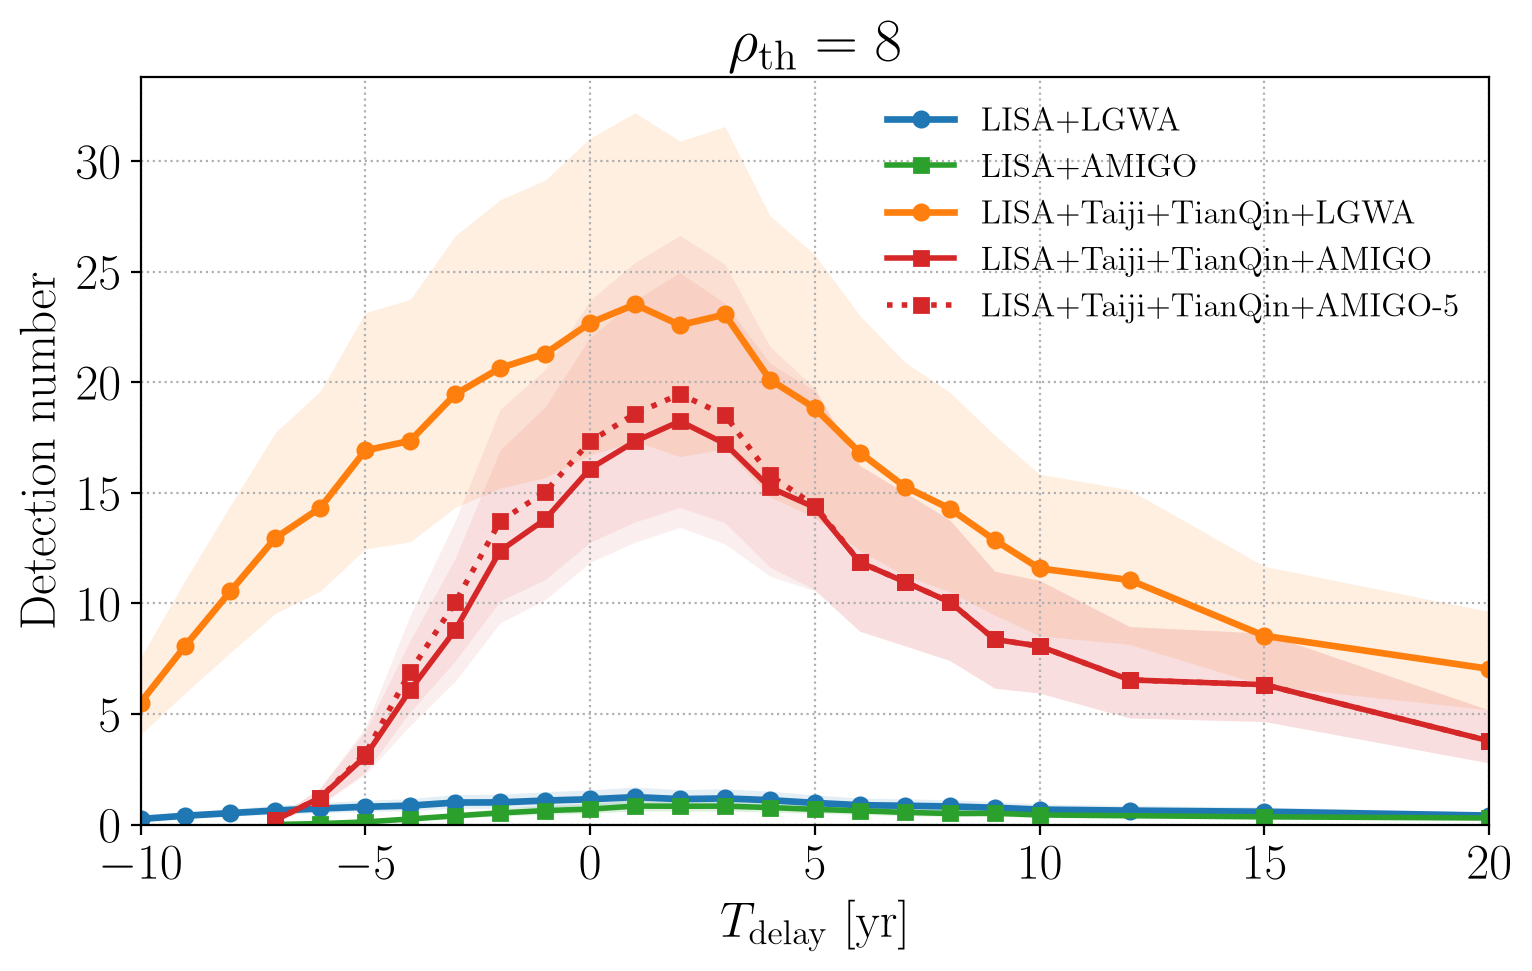

Saved plot to ../plots/space_event_count_lgwa_amigo_vs_Tdelay.png
Saved AMIGO comparison table to space_event_count_lgwa/lgwa_amigo_detection_number_vs_Tdelay_table.csv


In [23]:
# Compare the two requested space networks with LGWA and both AMIGO arm lengths.
LGWA_RESULT_DIR = Path('space_event_count_lgwa')
if not LGWA_RESULT_DIR.exists():
    LGWA_RESULT_DIR = Path('code/space_event_count_lgwa')
AMIGO_RESULT_DIR = Path('space_event_count_amigo')
if not AMIGO_RESULT_DIR.exists():
    AMIGO_RESULT_DIR = Path('code/space_event_count_amigo')

AMIGO_LENGTH_LABELS = {
    1.0e7: 'AMIGO',
    5.0e7: 'AMIGO-5',
}
TARGET_SPACE_NETWORKS = ['LISA', 'LISA-Taiji-TianQin']
# The current AMIGO directory stores its high-sensitivity space curve with
# space_detector_network='Taiji'. Use it as the requested combined-network
# curve until an exact LISA-Taiji-TianQin delay series is placed there.
AMIGO_NETWORK_FALLBACKS = {'Taiji': 'LISA-Taiji-TianQin'}


def rows_from_amigo_summary_file(path):
    rows = []
    for line in path.read_text().splitlines():
        item = parse_summary_line(line)
        if item is None or 'Tdelay_yr' not in item:
            continue
        source_network = item.get('space_detector_network') or detector_from_filename(path)
        plot_network = AMIGO_NETWORK_FALLBACKS.get(source_network, source_network)
        for arm_length, detection_number in item.get('Nspace_amigo_by_LAMIGO', {}).items():
            arm_length = float(arm_length)
            if arm_length not in AMIGO_LENGTH_LABELS:
                continue
            rows.append({
                'network': plot_network,
                'source_network': source_network,
                'used_network_fallback': source_network != plot_network,
                'Tdelay_yr': float(item['Tdelay_yr']),
                'LAMIGO_m': arm_length,
                'Nspace_followup': float(detection_number),
                'rho_thr': float(item.get('rho_thr', np.nan)),
                'z_max': float(item.get('z_max', np.nan)),
                'n_samples': int(item.get('n_samples', 0)),
                'source_file': path.name,
            })
    return rows


amigo_files = sorted(
    path for path in AMIGO_RESULT_DIR.glob('*.txt')
    if not path.name.endswith('_samples.txt')
)
amigo_rows = []
for path in amigo_files:
    amigo_rows.extend(rows_from_amigo_summary_file(path))

amigo_df = pd.DataFrame(amigo_rows)
if amigo_df.empty:
    raise RuntimeError(f'No AMIGO summary rows found in {AMIGO_RESULT_DIR}')
amigo_df = amigo_df[np.isclose(amigo_df['rho_thr'], 8.0)].copy()
if amigo_df.empty:
    raise RuntimeError(f'No rho=8 AMIGO summary rows found in {AMIGO_RESULT_DIR}')

# Prefer exact combined-network files if they are added later; otherwise use
# the documented Taiji fallback. Then prefer the largest simulation run.
amigo_df['exact_network'] = (~amigo_df['used_network_fallback']).astype(int)
amigo_plot_df = (
    amigo_df[amigo_df['network'].isin(TARGET_SPACE_NETWORKS)]
    .sort_values(['network', 'Tdelay_yr', 'LAMIGO_m', 'exact_network', 'z_max', 'n_samples'])
    .groupby(['network', 'Tdelay_yr', 'LAMIGO_m'], as_index=False)
    .tail(1)
    .sort_values(['network', 'LAMIGO_m', 'Tdelay_yr'])
    .reset_index(drop=True)
)

missing_networks = set(TARGET_SPACE_NETWORKS) - set(amigo_plot_df['network'])
if missing_networks:
    raise RuntimeError(f'Missing AMIGO delay series for: {sorted(missing_networks)}')

print(f'Read {len(amigo_files)} AMIGO summary files at rho=8 from {AMIGO_RESULT_DIR}')
for network in TARGET_SPACE_NETWORKS:
    delays = sorted(amigo_plot_df.loc[amigo_plot_df['network'] == network, 'Tdelay_yr'].unique())
    print(f'  {network}: Tdelay = {delays}')

fallback_sources = amigo_plot_df.loc[
    amigo_plot_df['used_network_fallback'], ['source_network', 'network']
].drop_duplicates()
if not fallback_sources.empty:
    print('AMIGO network-label fallback used:')
    for row in fallback_sources.itertuples(index=False):
        print(f'  {row.source_network} files -> {row.network} plot label')

curve_colors = {
    ('LISA', 'LGWA'): 'tab:blue',
    ('LISA-Taiji-TianQin', 'LGWA'): 'tab:orange',
    ('LISA', 'AMIGO'): 'tab:green',
    ('LISA-Taiji-TianQin', 'AMIGO'): 'tab:red',
}
network_display = {
    'LISA': 'LISA',
    'LISA-Taiji-TianQin': 'LISA+Taiji+TianQin',
}

lower_scale = 14.0 / 19.0
upper_scale = 26.0 / 19.0

fig, ax = plt.subplots(figsize=(8.0, 5.2))
for network in TARGET_SPACE_NETWORKS:
    label_prefix = network_display[network]

    lgwa_group = plot_df[plot_df['network'] == network].sort_values('Tdelay_yr')
    lgwa_color = curve_colors[(network, 'LGWA')]
    lgwa_x = lgwa_group['Tdelay_yr'].to_numpy()
    lgwa_y = lgwa_group['Nspace_lgwa'].to_numpy()
    ax.plot(
        lgwa_x, lgwa_y,
        color=lgwa_color, ls='-', marker='o', lw=2.4, ms=5.5,
        label=f'{label_prefix}+LGWA',
    )
    ax.fill_between(
        lgwa_x, lgwa_y * lower_scale, lgwa_y * upper_scale,
        color=lgwa_color, alpha=0.12, linewidth=0,
        # label=r'$R_0=14$--$26$' if network == TARGET_SPACE_NETWORKS[0] else '_nolegend_',
    )

    amigo_color = curve_colors[(network, 'AMIGO')]
    for arm_length, line_style in ((1.0e7, '-'), (5.0e7, ':')):
        amigo_group = amigo_plot_df[
            (amigo_plot_df['network'] == network)
            & np.isclose(amigo_plot_df['LAMIGO_m'], arm_length)
        ].sort_values('Tdelay_yr')
        amigo_x = amigo_group['Tdelay_yr'].to_numpy()
        amigo_y = amigo_group['Nspace_followup'].to_numpy()
        if network == 'LISA-Taiji-TianQin':
            ax.plot(
                amigo_x, amigo_y,
                color=amigo_color, ls=line_style, marker='s', lw=2.0, ms=5.0,
                label=f"{label_prefix}+{AMIGO_LENGTH_LABELS[arm_length]}",
            )
        elif network == 'LISA' and arm_length == 1.0e7:
            ax.plot(
                amigo_x, amigo_y,
                color=amigo_color, ls=line_style, marker='s', lw=2.0, ms=5.0,
                label=f"{label_prefix}+{AMIGO_LENGTH_LABELS[arm_length]}",
            )
        ax.fill_between(
            amigo_x, amigo_y * lower_scale, amigo_y * upper_scale,
            color=amigo_color, alpha=0.08, linewidth=0,
        )

ax.set_xlim(-10, 20)
ax.set_ylim(bottom=0)
ax.set_xlabel(r'$T_{\rm delay}$ [yr]')
ax.set_ylabel('Detection number')
ax.set_title(r'$\rho_{\rm th}=8$')
ax.legend(frameon=False, fontsize=12)
plt.tight_layout()
comparison_plot_path = Path('../plots/space_event_count_lgwa_amigo_vs_Tdelay.png')
comparison_plot_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(comparison_plot_path, dpi=300, bbox_inches='tight')
plt.show()

comparison_table_path = LGWA_RESULT_DIR / 'lgwa_amigo_detection_number_vs_Tdelay_table.csv'
amigo_plot_df.to_csv(comparison_table_path, index=False)
print(f'Saved plot to {comparison_plot_path}')
print(f'Saved AMIGO comparison table to {comparison_table_path}')


Read 6 AMIGO summary files at rho=5 from space_event_count_amigo/rho5
  LISA: Tdelay = [np.float64(-7.0), np.float64(-6.0), np.float64(-5.0), np.float64(-4.0), np.float64(-3.0), np.float64(-2.0), np.float64(-1.0), np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0), np.float64(9.0), np.float64(10.0), np.float64(12.0), np.float64(15.0), np.float64(20.0)]
  LISA-Taiji-TianQin: Tdelay = [np.float64(-7.0), np.float64(-6.0), np.float64(-5.0), np.float64(-4.0), np.float64(-3.0), np.float64(-2.0), np.float64(-1.0), np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0), np.float64(9.0), np.float64(10.0), np.float64(12.0), np.float64(15.0), np.float64(20.0)]


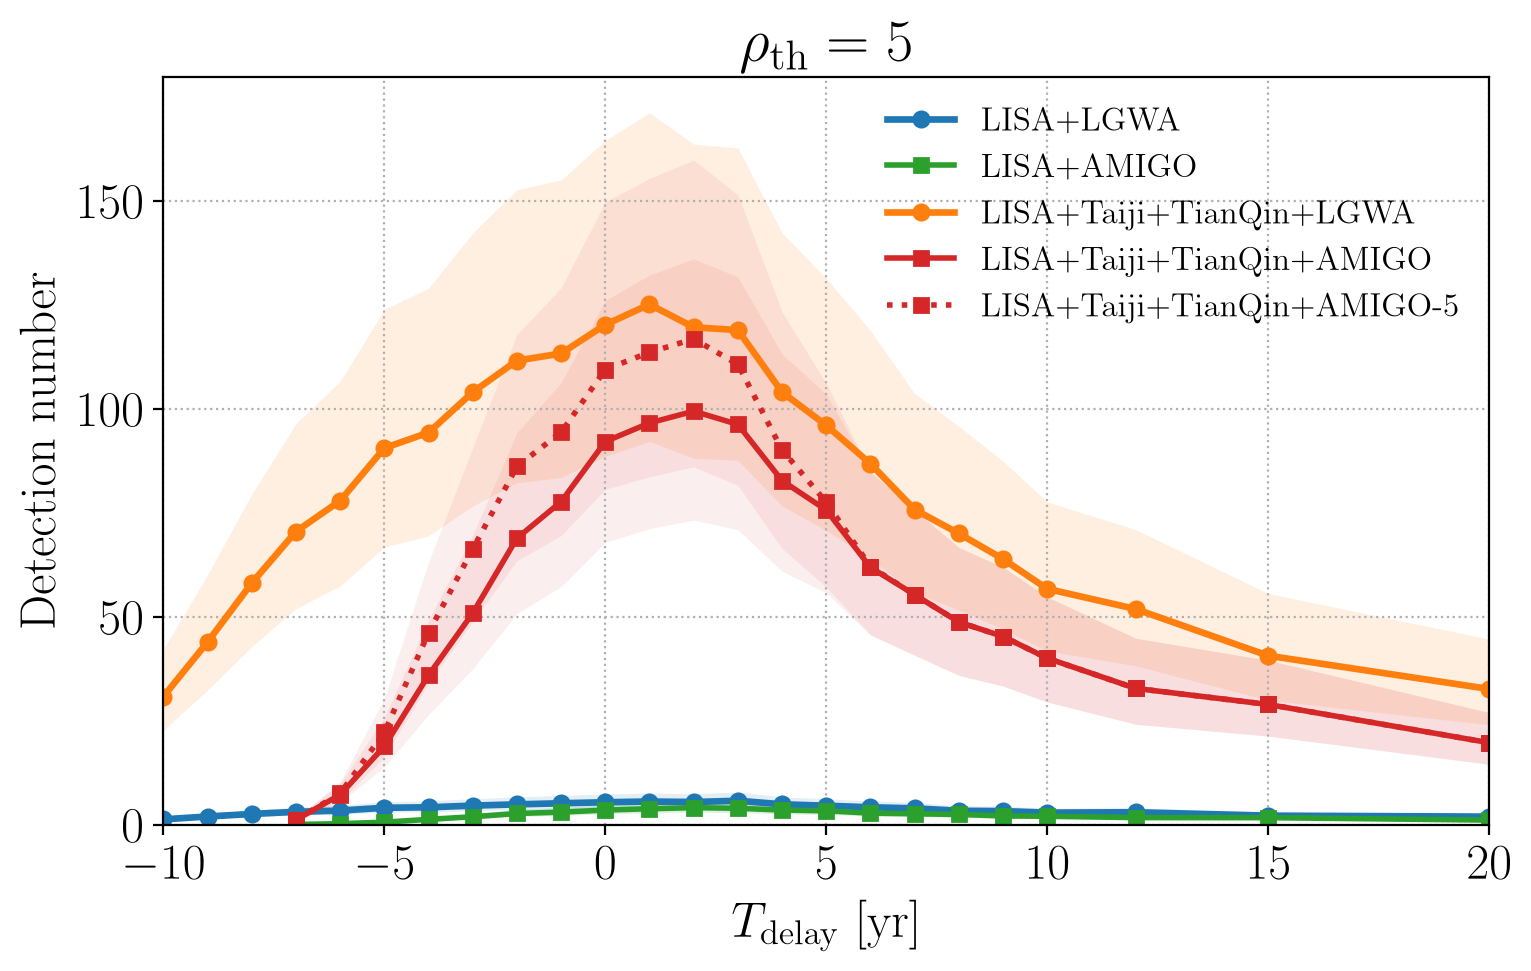

Saved plot to ../plots/space_event_count_lgwa_amigo_rho5_vs_Tdelay.png
Saved AMIGO comparison table to space_event_count_lgwa/rho_5/lgwa_amigo_detection_number_vs_Tdelay_table.csv


In [24]:
# Repeat the LGWA/AMIGO comparison for rho=5.
AMIGO_RHO5_RESULT_DIR = Path('space_event_count_amigo/rho5')
if not AMIGO_RHO5_RESULT_DIR.exists():
    AMIGO_RHO5_RESULT_DIR = Path('code/space_event_count_amigo/rho5')
LGWA_RHO5_RESULT_DIR = Path('space_event_count_lgwa/rho_5')
if not LGWA_RHO5_RESULT_DIR.exists():
    LGWA_RHO5_RESULT_DIR = Path('code/space_event_count_lgwa/rho_5')

amigo_rho5_files = sorted(
    path for path in AMIGO_RHO5_RESULT_DIR.glob('*.txt')
    if not path.name.endswith('_samples.txt')
)
amigo_rho5_rows = []
for path in amigo_rho5_files:
    amigo_rho5_rows.extend(rows_from_amigo_summary_file(path))

amigo_rho5_df = pd.DataFrame(amigo_rho5_rows)
if amigo_rho5_df.empty:
    raise RuntimeError(f'No AMIGO summary rows found in {AMIGO_RHO5_RESULT_DIR}')
amigo_rho5_df = amigo_rho5_df[np.isclose(amigo_rho5_df['rho_thr'], 5.0)].copy()
amigo_rho5_df['exact_network'] = (~amigo_rho5_df['used_network_fallback']).astype(int)
amigo_rho5_plot_df = (
    amigo_rho5_df[amigo_rho5_df['network'].isin(TARGET_SPACE_NETWORKS)]
    .sort_values(['network', 'Tdelay_yr', 'LAMIGO_m', 'exact_network', 'z_max', 'n_samples'])
    .groupby(['network', 'Tdelay_yr', 'LAMIGO_m'], as_index=False)
    .tail(1)
    .sort_values(['network', 'LAMIGO_m', 'Tdelay_yr'])
    .reset_index(drop=True)
)

missing_rho5_networks = set(TARGET_SPACE_NETWORKS) - set(amigo_rho5_plot_df['network'])
if missing_rho5_networks:
    raise RuntimeError(f'Missing rho=5 AMIGO delay series for: {sorted(missing_rho5_networks)}')

print(f'Read {len(amigo_rho5_files)} AMIGO summary files at rho=5 from {AMIGO_RHO5_RESULT_DIR}')
for network in TARGET_SPACE_NETWORKS:
    delays = sorted(amigo_rho5_plot_df.loc[amigo_rho5_plot_df['network'] == network, 'Tdelay_yr'].unique())
    print(f'  {network}: Tdelay = {delays}')

fig, ax = plt.subplots(figsize=(8.0, 5.2))
for network in TARGET_SPACE_NETWORKS:
    label_prefix = network_display[network]
    lgwa_group = plot_df_rho5[plot_df_rho5['network'] == network].sort_values('Tdelay_yr')
    lgwa_color = curve_colors[(network, 'LGWA')]
    lgwa_x = lgwa_group['Tdelay_yr'].to_numpy()
    lgwa_y = lgwa_group['Nspace_lgwa'].to_numpy()
    ax.plot(lgwa_x, lgwa_y, color=lgwa_color, ls='-', marker='o', lw=2.4, ms=5.5, label=f'{label_prefix}+LGWA')
    ax.fill_between(lgwa_x, lgwa_y * lower_scale, lgwa_y * upper_scale, color=lgwa_color, alpha=0.12, linewidth=0)

    amigo_color = curve_colors[(network, 'AMIGO')]
    for arm_length, line_style in ((1.0e7, '-'), (5.0e7, ':')):
        amigo_group = amigo_rho5_plot_df[
            (amigo_rho5_plot_df['network'] == network)
            & np.isclose(amigo_rho5_plot_df['LAMIGO_m'], arm_length)
        ].sort_values('Tdelay_yr')
        amigo_x = amigo_group['Tdelay_yr'].to_numpy()
        amigo_y = amigo_group['Nspace_followup'].to_numpy()
        if network == 'LISA-Taiji-TianQin':
            ax.plot(
                amigo_x, amigo_y,
                color=amigo_color, ls=line_style, marker='s', lw=2.0, ms=5.0,
                label=f"{label_prefix}+{AMIGO_LENGTH_LABELS[arm_length]}",
            )
        elif network == 'LISA' and arm_length == 1.0e7:
            ax.plot(
                amigo_x, amigo_y,
                color=amigo_color, ls=line_style, marker='s', lw=2.0, ms=5.0,
                label=f"{label_prefix}+{AMIGO_LENGTH_LABELS[arm_length]}",
            )        
        ax.fill_between(amigo_x, amigo_y * lower_scale, amigo_y * upper_scale, color=amigo_color, alpha=0.08, linewidth=0)

ax.set_xlim(-10, 20)
ax.set_ylim(bottom=0)
ax.set_xlabel(r'$T_{\rm delay}$ [yr]')
ax.set_ylabel('Detection number')
ax.set_title(r'$\rho_{\rm th}=5$')
ax.legend(frameon=False, fontsize=12)
plt.tight_layout()
rho5_comparison_plot_path = Path('../plots/space_event_count_lgwa_amigo_rho5_vs_Tdelay.png')
rho5_comparison_plot_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(rho5_comparison_plot_path, dpi=300, bbox_inches='tight')
plt.show()

rho5_comparison_table_path = LGWA_RHO5_RESULT_DIR / 'lgwa_amigo_detection_number_vs_Tdelay_table.csv'
amigo_rho5_plot_df.to_csv(rho5_comparison_table_path, index=False)
print(f'Saved plot to {rho5_comparison_plot_path}')
print(f'Saved AMIGO comparison table to {rho5_comparison_table_path}')
